# EE 344 Final Project — Mid Project Review
## Predicting Social Media Addiction Among Students

This notebook contains:
- Data loading & quick EDA
- Preprocessing pipeline (One-hot + scaling)
- Baseline machine learning models:
  - Linear Regression
  - KNN Regressor
  - Random Forest Regressor
- Evaluation using MAE, MSE, RMSE, and R²
- Feature importance analysis (Random Forest)

In [41]:
import os
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## 1) Load dataset

We load the Kaggle robotic operations dataset and check:
- shape (rows/cols)
- column names
- basic dtypes

In [42]:
CSV_PATH = "/content/Students Social Media Addiction.csv"  # <- change this if your filename differs

if not os.path.exists(CSV_PATH):
    raise FileNotFoundError(f"Cannot find {CSV_PATH}. Make sure it is in the same folder as this notebook.")

df = pd.read_csv(CSV_PATH)

print("Shape:", df.shape)
display(df.head())


Shape: (705, 13)


,Student_ID,Age,Gender,Academic_Level,Country,Avg_Daily_Usage_Hours,Most_Used_Platform,Affects_Academic_Performance,Sleep_Hours_Per_Night,Mental_Health_Score,Relationship_Status,Conflicts_Over_Social_Media,Addicted_Score
0,1,19,Female,Undergraduate,Bangladesh,5.2,Instagram,Yes,6.5,6,In Relationship,3,8
1,2,22,Male,Graduate,India,2.1,Twitter,No,7.5,8,Single,0,3
2,3,20,Female,Undergraduate,USA,6.0,TikTok,Yes,5.0,5,Complicated,4,9
3,4,18,Male,High School,UK,3.0,YouTube,No,7.0,7,Single,1,4
4,5,21,Male,Graduate,Canada,4.5,Facebook,Yes,6.0,6,In Relationship,2,7


## 2) Quick data overview

We inspect data types and missing values to decide preprocessing steps.

In [43]:
display(df.info())

missing_counts = df.isna().sum().sort_values(ascending=False)
display(missing_counts[missing_counts > 0])

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 705 entries, 0 to 704
Data columns (total 13 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Student_ID                    705 non-null    int64  
 1   Age                           705 non-null    int64  
 2   Gender                        705 non-null    object 
 3   Academic_Level                705 non-null    object 
 4   Country                       705 non-null    object 
 5   Avg_Daily_Usage_Hours         705 non-null    float64
 6   Most_Used_Platform            705 non-null    object 
 7   Affects_Academic_Performance  705 non-null    object 
 8   Sleep_Hours_Per_Night         705 non-null    float64
 9   Mental_Health_Score           705 non-null    int64  
 10  Relationship_Status           705 non-null    object 
 11  Conflicts_Over_Social_Media   705 non-null    int64  
 12  Addicted_Score                705 non-null    int64  
dtypes: fl

None

,0


## 3) Target (Addicted_Score) distribution

We visualize the distribution of the target variable to understand its range and variance.
If the variance is very small, the regression model may have difficulty learning meaningful patterns.

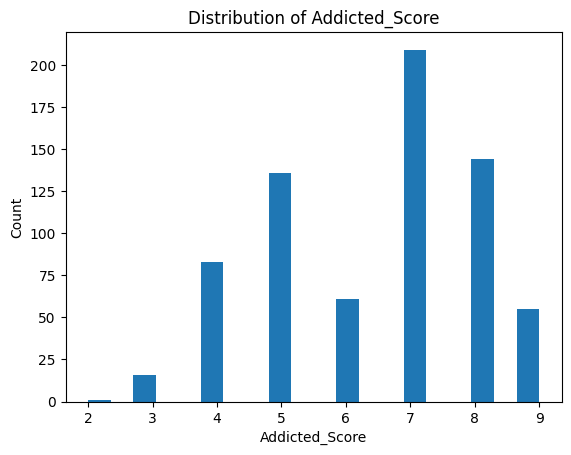

Accuracy describe:


,Addicted_Score
count,705.000000
mean,6.436879
std,1.587165
min,2.000000
25%,5.000000
50%,7.000000
75%,8.000000
max,9.000000


In [44]:
TARGET_COL = "Addicted_Score"

if TARGET_COL not in df.columns:
    raise ValueError(f"age'{TARGET_COL}' not found. Columns are: {list(df.columns)}")

plt.figure()
plt.hist(df[TARGET_COL].dropna(), bins=20)
plt.title("Distribution of Addicted_Score")
plt.xlabel("Addicted_Score")
plt.ylabel("Count")
plt.show()

print("Accuracy describe:")
display(df[TARGET_COL].describe())

## 4) Identify feature columns

We split the dataset into:
- X: all columns except the addiction score
- y: Addicted_Score

Then we automatically detect:
- categorical columns (object/string)
- numeric columns (int/float)

In [45]:

X = df.drop(columns=[TARGET_COL, "Student_ID", "Mental_Health_Score"])
y = df[TARGET_COL]

categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()
numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()



print("Categorical columns:", categorical_cols)
print("Numeric columns:", numeric_cols)

print("Columns:")
print(df.columns)

print("\nCurrent TARGET_COL:")
print(TARGET_COL)

print("\nTarget describe:")
print(df[TARGET_COL].describe())

print(df.dtypes.value_counts())
obj_cols = df.select_dtypes(include=["object"]).columns.tolist()
print("Object cols count:", len(obj_cols))
print(obj_cols[:30])

Categorical columns: ['Gender', 'Academic_Level', 'Country', 'Most_Used_Platform', 'Affects_Academic_Performance', 'Relationship_Status']
Numeric columns: ['Age', 'Avg_Daily_Usage_Hours', 'Sleep_Hours_Per_Night', 'Conflicts_Over_Social_Media']
Columns:
Index(['Student_ID', 'Age', 'Gender', 'Academic_Level', 'Country',
       'Avg_Daily_Usage_Hours', 'Most_Used_Platform',
       'Affects_Academic_Performance', 'Sleep_Hours_Per_Night',
       'Mental_Health_Score', 'Relationship_Status',
       'Conflicts_Over_Social_Media', 'Addicted_Score'],
      dtype='object')

Current TARGET_COL:
Addicted_Score

Target describe:
count    705.000000
mean       6.436879
std        1.587165
min        2.000000
25%        5.000000
50%        7.000000
75%        8.000000
max        9.000000
Name: Addicted_Score, dtype: float64
object     6
int64      5
float64    2
Name: count, dtype: int64
Object cols count: 6
['Gender', 'Academic_Level', 'Country', 'Most_Used_Platform', 'Affects_Academic_Performance',

## 5) Numeric feature correlation

We check correlations among numeric features (not including target).
If there are highly correlated features, we might remove one later (optional).

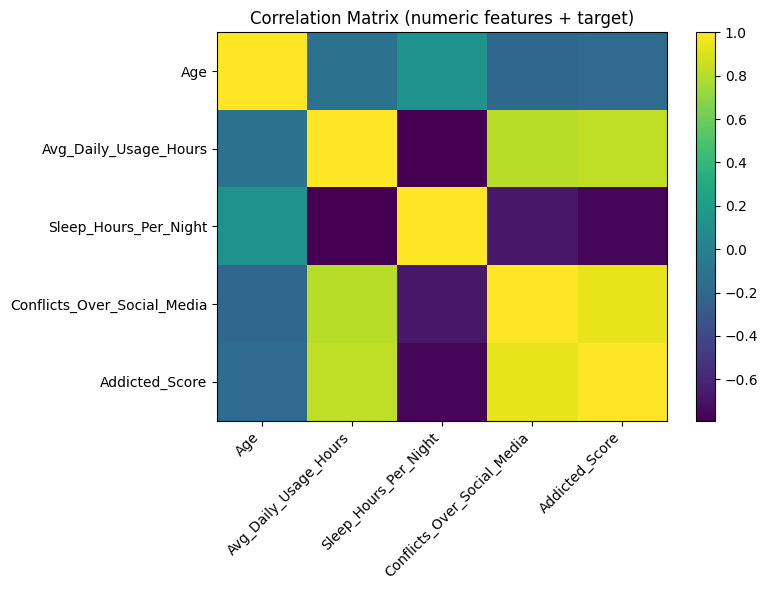

In [46]:
if len(numeric_cols) > 1:
    corr = df[numeric_cols + [TARGET_COL]].corr(numeric_only=True)

    plt.figure(figsize=(8, 6))
    plt.imshow(corr, aspect="auto")
    plt.title("Correlation Matrix (numeric features + target)")
    plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha="right")
    plt.yticks(range(len(corr.index)), corr.index)
    plt.colorbar()
    plt.tight_layout()
    plt.show()
else:
    print("Not enough numeric features for correlation matrix.")

## 6) Train/Test split

We use an 80/20 split as planned in the proposal.

In [47]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Train shape:", X_train.shape, "Test shape:", X_test.shape)

Train shape: (564, 10) Test shape: (141, 10)


## 7) Preprocessing pipeline

We build a sklearn `ColumnTransformer`:
- Numeric columns:
  - Impute missing values with median
  - Standardize (mean=0, std=1)
- Categorical columns:
  - Impute missing values with most frequent
  - One-hot encode

This makes the training reproducible and clean.

In [48]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, categorical_cols)
    ],
    remainder="drop"
)

## 8) Evaluation helper

We report:
- MAE
- MSE
- RMSE
- R²

In [49]:
def evaluate_regression(model, X_train, y_train, X_test, y_test, name="Model"):

    # predictions
    train_pred = model.predict(X_train)
    test_pred  = model.predict(X_test)

    # Train metrics
    train_mae = mean_absolute_error(y_train, train_pred)
    train_rmse = np.sqrt(mean_squared_error(y_train, train_pred))
    train_r2 = r2_score(y_train, train_pred)

    # Test metrics
    test_mae = mean_absolute_error(y_test, test_pred)
    test_rmse = np.sqrt(mean_squared_error(y_test, test_pred))
    test_r2 = r2_score(y_test, test_pred)

    return {
        "Model": name,
        "Train MAE": train_mae,
        "Train RMSE": train_rmse,
        "Train R2": train_r2,
        "Test MAE": test_mae,
        "Test RMSE": test_rmse,
        "Test R2": test_r2
    }

## 9) Model 1 — Linear Regression (baseline)

This is a simple baseline model.
It assumes a mostly linear relationship between behavioral features and the social media addiction score.

In [50]:
linreg = Pipeline(steps=[
    ("prep", preprocessor),
    ("model", LinearRegression())
])

linreg.fit(X_train, y_train)
y_pred_lr = linreg.predict(X_test)

results = []
linreg.fit(X_train, y_train)

results.append(
    evaluate_regression(
        linreg,
        X_train, y_train,
        X_test, y_test,
        name="Linear Regression"
    )
)

pd.DataFrame(results)

,Model,Train MAE,Train RMSE,Train R2,Test MAE,Test RMSE,Test R2
0,Linear Regression,0.178927,0.263582,0.972402,0.257153,0.385716,0.940544


## 10) Model 2 — KNN Regressor

KNN can capture local patterns without assuming linearity.
We choose a small k as a starting point and can tune later.

In [51]:
knn = Pipeline(steps=[
    ("prep", preprocessor),
    ("model", KNeighborsRegressor(n_neighbors=5))
])

knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)
knn.fit(X_train, y_train)

results.append(
    evaluate_regression(
        knn,
        X_train, y_train,
        X_test, y_test,
        name="KNN (k=5)"
    )
)
pd.DataFrame(results)

,Model,Train MAE,Train RMSE,Train R2,Test MAE,Test RMSE,Test R2
0,Linear Regression,0.178927,0.263582,0.972402,0.257153,0.385716,0.940544
1,KNN (k=5),0.092199,0.203515,0.983547,0.117730,0.246967,0.975625


## 11) Model 3 — Random Forest Regressor

Random Forest is a strong nonlinear model and can handle feature interactions.
We start with default-ish parameters and tune later.

In [52]:
rf = Pipeline(steps=[
    ("prep", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=300,
        random_state=42
    ))
])

rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

rf.fit(X_train, y_train)

results.append(
    evaluate_regression(
        rf,
        X_train, y_train,
        X_test, y_test,
        name="Random Forest (300 trees)"
    )
)
pd.DataFrame(results).sort_values("Test R2", ascending=False)

,Model,Train MAE,Train RMSE,Train R2,Test MAE,Test RMSE,Test R2
2,Random Forest (300 trees),0.031998,0.081022,0.997392,0.082861,0.219658,0.980718
1,KNN (k=5),0.092199,0.203515,0.983547,0.117730,0.246967,0.975625
0,Linear Regression,0.178927,0.263582,0.972402,0.257153,0.385716,0.940544


## 12) Predicted vs True plot

We visualize how close predictions are to the true addiction scores.
A perfect model would lie on the diagonal line.

,Model,Train MAE,Train RMSE,Train R2,Test MAE,Test RMSE,Test R2
0,Random Forest (300 trees),0.031998,0.081022,0.997392,0.082861,0.219658,0.980718
1,KNN (k=5),0.092199,0.203515,0.983547,0.117730,0.246967,0.975625
2,Linear Regression,0.178927,0.263582,0.972402,0.257153,0.385716,0.940544


Best model by R2: Random Forest (300 trees)


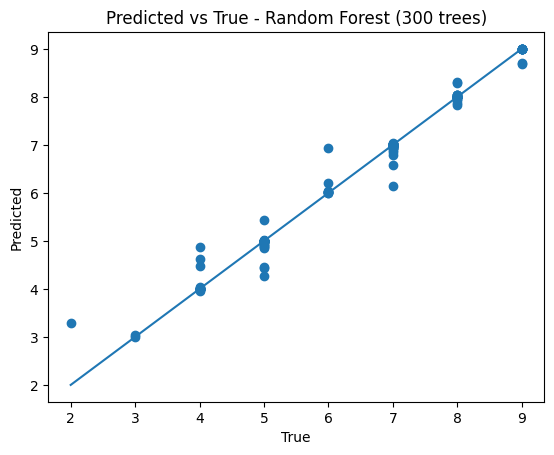

In [53]:
# pick best model by R2
results_df = pd.DataFrame(results).sort_values("Test R2", ascending=False).reset_index(drop=True)
display(results_df)

best_name = results_df.loc[0, "Model"]
print("Best model by R2:", best_name)

pred_map = {
    "Linear Regression": y_pred_lr,
    "KNN (k=5)": y_pred_knn,
    "Random Forest (300 trees)": y_pred_rf
}
best_pred = pred_map[best_name]

plt.figure()
plt.scatter(y_test, best_pred)
plt.title(f"Predicted vs True - {best_name}")
plt.xlabel("True")
plt.ylabel("Predicted")

# diagonal reference
min_v = min(y_test.min(), best_pred.min())
max_v = max(y_test.max(), best_pred.max())
plt.plot([min_v, max_v], [min_v, max_v])
plt.show()

## 13) Feature importance (Random Forest)

Random Forest provides a measure of feature importance.
This helps explain which behavioral and lifestyle factors most influence social media addiction levels.
Note: One-hot encoding expands categorical variables into multiple columns.

,feature,importance
109,Affects_Academic_Performance_Yes,0.369032
108,Affects_Academic_Performance_No,0.358078
3,Conflicts_Over_Social_Media,0.163506
1,Avg_Daily_Usage_Hours,0.026683
2,Sleep_Hours_Per_Night,0.017643
91,Country_USA,0.011269
40,Country_India,0.007203
45,Country_Japan,0.005564
42,Country_Ireland,0.004774
99,Most_Used_Platform_LINE,0.003560


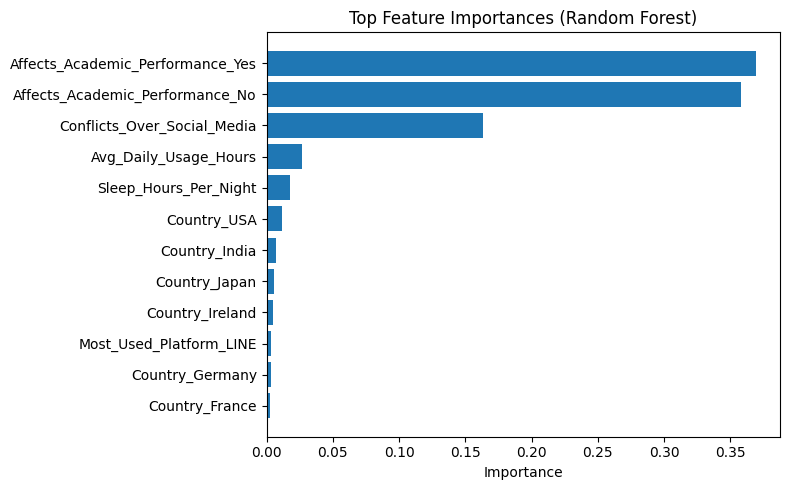

In [54]:
# Get feature names after preprocessing
# Works for sklearn >= 1.0
ohe = rf.named_steps["prep"].named_transformers_["cat"].named_steps["onehot"]

cat_feature_names = []
if len(categorical_cols) > 0:
    cat_feature_names = ohe.get_feature_names_out(categorical_cols).tolist()

feature_names = numeric_cols + cat_feature_names

importances = rf.named_steps["model"].feature_importances_

imp_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

display(imp_df.head(15))

plt.figure(figsize=(8, 5))
top_k = 12
plt.barh(imp_df["feature"].head(top_k)[::-1], imp_df["importance"].head(top_k)[::-1])
plt.title("Top Feature Importances (Random Forest)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

## 14) Save results table

We export the model comparison table so we can include it later in the final report.

In [55]:
results_df = pd.DataFrame(results).sort_values("Test R2", ascending=False)
results_df.to_csv("results_model_comparison.csv", index=False)
print("Saved: results_model_comparison.csv")
display(results_df)

Saved: results_model_comparison.csv


,Model,Train MAE,Train RMSE,Train R2,Test MAE,Test RMSE,Test R2
2,Random Forest (300 trees),0.031998,0.081022,0.997392,0.082861,0.219658,0.980718
1,KNN (k=5),0.092199,0.203515,0.983547,0.117730,0.246967,0.975625
0,Linear Regression,0.178927,0.263582,0.972402,0.257153,0.385716,0.940544


## 15) Gradient Boosting Regressor

In addition to Linear Regression, KNN, and Random Forest, we include a **Gradient Boosting Regressor** as a stronger tabular model. Gradient boosting builds trees sequentially, where each new tree focuses on correcting the errors made by the previous ones. This often improves performance on structured/tabular datasets.

We train the model using the same preprocessing pipeline and evaluate it on the same 80/20 train-test split to keep the comparison consistent with the previous models.

In [56]:
from sklearn.ensemble import GradientBoostingRegressor

gbr = Pipeline(steps=[
    ("prep", preprocessor),
    ("model", GradientBoostingRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ))
])

gbr.fit(X_train, y_train)
y_pred_gbr = gbr.predict(X_test)

gbr.fit(X_train, y_train)

results.append(
    evaluate_regression(
        gbr,
        X_train, y_train,
        X_test, y_test,
        name="Gradient Boosting"
    )
)
pd.DataFrame(results).sort_values("Test R2", ascending=False)

,Model,Train MAE,Train RMSE,Train R2,Test MAE,Test RMSE,Test R2
2,Random Forest (300 trees),0.031998,0.081022,0.997392,0.082861,0.219658,0.980718
3,Gradient Boosting,0.119526,0.175505,0.987764,0.153100,0.244916,0.976028
1,KNN (k=5),0.092199,0.203515,0.983547,0.117730,0.246967,0.975625
0,Linear Regression,0.178927,0.263582,0.972402,0.257153,0.385716,0.940544


## 16) Small Hyperparameter Search

To further improve model performance, we perform a small hyperparameter search on the main models used in this project.

The goal is not to exhaustively search all combinations, but to test a few important parameters that typically affect model performance:

- **KNN**: number of neighbors (k)
- **Random Forest**: tree depth and minimum leaf size
- **Gradient Boosting**: tree depth and learning rate

We use **GridSearchCV with 5-fold cross-validation** on the training set to select the best parameter combinations. The best models are then evaluated on the same test set used earlier so that results remain comparable across models.

In [57]:
from sklearn.model_selection import GridSearchCV

knn_pipe = Pipeline(steps=[
    ("prep", preprocessor),
    ("model", KNeighborsRegressor())
])

param_grid_knn = {
    "model__n_neighbors": [3,5,7,9,11],
    "model__weights": ["uniform","distance"]
}

knn_search = GridSearchCV(
    knn_pipe,
    param_grid_knn,
    cv=5,
    scoring="neg_root_mean_squared_error"
)

knn_search.fit(X_train, y_train)

best_knn = knn_search.best_estimator_

results.append(
    evaluate_regression(
        best_knn,
        X_train, y_train,
        X_test, y_test,
        name="KNN (tuned)"
    )
)

print("Best KNN params:", knn_search.best_params_)
pd.DataFrame(results).sort_values("Test R2", ascending=False)

Best KNN params: {'model__n_neighbors': 3, 'model__weights': 'distance'}


,Model,Train MAE,Train RMSE,Train R2,Test MAE,Test RMSE,Test R2
4,KNN (tuned),0.000000,0.000000,1.000000,0.071618,0.200643,0.983912
2,Random Forest (300 trees),0.031998,0.081022,0.997392,0.082861,0.219658,0.980718
3,Gradient Boosting,0.119526,0.175505,0.987764,0.153100,0.244916,0.976028
1,KNN (k=5),0.092199,0.203515,0.983547,0.117730,0.246967,0.975625
0,Linear Regression,0.178927,0.263582,0.972402,0.257153,0.385716,0.940544


In [58]:
rf_pipe = Pipeline(steps=[
    ("prep", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=300,
        random_state=42
    ))
])

param_grid_rf = {
    "model__max_depth":[None,10,20],
    "model__min_samples_leaf":[1,2,4]
}

rf_search = GridSearchCV(
    rf_pipe,
    param_grid_rf,
    cv=5,
    scoring="neg_root_mean_squared_error"
)

rf_search.fit(X_train, y_train)

best_rf = rf_search.best_estimator_

results.append(
    evaluate_regression(
        best_rf,
        X_train, y_train,
        X_test, y_test,
        name="Random Forest (tuned)"
    )
)

print("Best RF params:", rf_search.best_params_)
pd.DataFrame(results).sort_values("Test R2", ascending=False)

Best RF params: {'model__max_depth': 10, 'model__min_samples_leaf': 1}


,Model,Train MAE,Train RMSE,Train R2,Test MAE,Test RMSE,Test R2
4,KNN (tuned),0.000000,0.000000,1.000000,0.071618,0.200643,0.983912
5,Random Forest (tuned),0.036827,0.095886,0.996348,0.083206,0.217862,0.981032
2,Random Forest (300 trees),0.031998,0.081022,0.997392,0.082861,0.219658,0.980718
3,Gradient Boosting,0.119526,0.175505,0.987764,0.153100,0.244916,0.976028
1,KNN (k=5),0.092199,0.203515,0.983547,0.117730,0.246967,0.975625
0,Linear Regression,0.178927,0.263582,0.972402,0.257153,0.385716,0.940544


In [60]:
gbr_pipe = Pipeline(steps=[
    ("prep", preprocessor),
    ("model", GradientBoostingRegressor(
        n_estimators=200,
        random_state=42
    ))
])

param_grid_gbr = {
    "model__max_depth": [2, 3, 4],
    "model__learning_rate": [0.03, 0.05, 0.1]
}

gbr_search = GridSearchCV(
    gbr_pipe,
    param_grid_gbr,
    cv=5,
    scoring="neg_root_mean_squared_error"
)

gbr_search.fit(X_train, y_train)

best_gbr = gbr_search.best_estimator_

results.append(
    evaluate_regression(
        best_gbr,
        X_train, y_train,
        X_test, y_test,
        name="Gradient Boosting (tuned)"
    )
)

print("Best GBR params:", gbr_search.best_params_)
pd.DataFrame(results).sort_values("Test R2", ascending=False)

Best GBR params: {'model__learning_rate': 0.1, 'model__max_depth': 3}


,Model,Train MAE,Train RMSE,Train R2,Test MAE,Test RMSE,Test R2
4,KNN (tuned),0.000000,0.000000,1.000000,0.071618,0.200643,0.983912
5,Random Forest (tuned),0.036827,0.095886,0.996348,0.083206,0.217862,0.981032
2,Random Forest (300 trees),0.031998,0.081022,0.997392,0.082861,0.219658,0.980718
6,Gradient Boosting (tuned),0.081824,0.129273,0.993362,0.124862,0.221257,0.980436
3,Gradient Boosting,0.119526,0.175505,0.987764,0.153100,0.244916,0.976028
1,KNN (k=5),0.092199,0.203515,0.983547,0.117730,0.246967,0.975625
0,Linear Regression,0.178927,0.263582,0.972402,0.257153,0.385716,0.940544


## 17) 5-fold cross-validation (mean +/- std)

The original 80/20 split is still useful, but a single split can be noisy. To strengthen evaluation rigor, we add **5-fold cross-validation** and report **mean +/- standard deviation** for MAE, RMSE, and R2.

This lets us compare model stability, not just the performance of one lucky split.

Best model by R2: Random Forest (tuned)


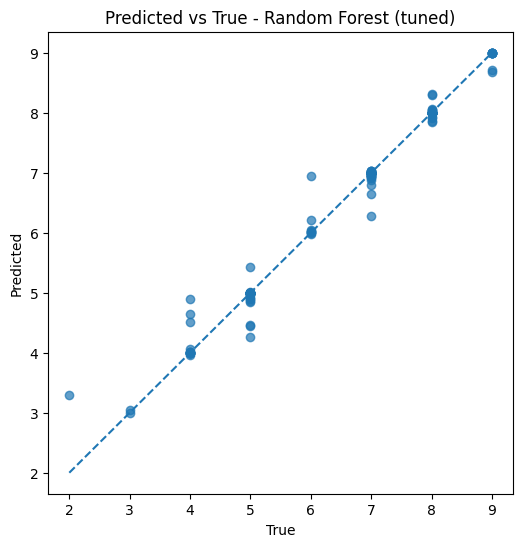

Saved: results_cross_validation_summary.csv


,Model,CV MAE (mean +/- std),CV RMSE (mean +/- std),CV R2 (mean +/- std)
0,Random Forest (tuned),0.083 +/- 0.018,0.214 +/- 0.038,0.982 +/- 0.005
1,Gradient Boosting (tuned),0.130 +/- 0.017,0.222 +/- 0.033,0.980 +/- 0.004
2,KNN (tuned),0.085 +/- 0.021,0.228 +/- 0.036,0.979 +/- 0.006
3,Linear Regression,0.237 +/- 0.030,0.348 +/- 0.054,0.951 +/- 0.012


In [61]:
from sklearn.model_selection import KFold, cross_validate

cv = KFold(n_splits=5, shuffle=True, random_state=42)
scoring = {
    "MAE": "neg_mean_absolute_error",
    "RMSE": "neg_root_mean_squared_error",
    "R2": "r2"
}

best_estimators = {
    "Linear Regression": linreg,
    "KNN (tuned)": best_knn,
    "Random Forest (tuned)": best_rf,
    "Gradient Boosting (tuned)": best_gbr
}

cv_rows = []
for name, model in best_estimators.items():
    scores = cross_validate(
        model,
        X,
        y,
        cv=cv,
        scoring=scoring,
        n_jobs=1
    )

    mae_scores = -scores["test_MAE"]
    rmse_scores = -scores["test_RMSE"]
    r2_scores = scores["test_R2"]

    cv_rows.append({
        "Model": name,
        "CV_MAE_mean": mae_scores.mean(),
        "CV_MAE_std": mae_scores.std(),
        "CV_RMSE_mean": rmse_scores.mean(),
        "CV_RMSE_std": rmse_scores.std(),
        "CV_R2_mean": r2_scores.mean(),
        "CV_R2_std": r2_scores.std()
    })

cv_results_df = pd.DataFrame(cv_rows).sort_values("CV_R2_mean", ascending=False).reset_index(drop=True)

cv_display_df = cv_results_df[["Model"]].copy()
cv_display_df["CV MAE (mean +/- std)"] = cv_results_df.apply(
    lambda row: f"{row['CV_MAE_mean']:.3f} +/- {row['CV_MAE_std']:.3f}", axis=1
)
cv_display_df["CV RMSE (mean +/- std)"] = cv_results_df.apply(
    lambda row: f"{row['CV_RMSE_mean']:.3f} +/- {row['CV_RMSE_std']:.3f}", axis=1
)
cv_display_df["CV R2 (mean +/- std)"] = cv_results_df.apply(
    lambda row: f"{row['CV_R2_mean']:.3f} +/- {row['CV_R2_std']:.3f}", axis=1
)

best_name = cv_results_df.loc[0, "Model"]
print("Best model by R2:", best_name)

best_model = best_estimators[best_name]
best_pred = best_model.predict(X_test)

plt.figure(figsize=(6, 6))
plt.scatter(y_test, best_pred, alpha=0.7)
plt.title(f"Predicted vs True - {best_name}")
plt.xlabel("True")
plt.ylabel("Predicted")

# diagonal reference
min_v = min(y_test.min(), best_pred.min())
max_v = max(y_test.max(), best_pred.max())
plt.plot([min_v, max_v], [min_v, max_v], linestyle="--")
plt.show()

cv_results_df.to_csv("results_cross_validation_summary.csv", index=False)
print("Saved: results_cross_validation_summary.csv")
display(cv_display_df)

## 18) Division of Labor

To ensure clear responsibilities and efficient collaboration, the project work is divided between the two team members as follows.

**Yifei Luo**

Responsible for:
- Data preprocessing and feature preparation
- Exploratory Data Analysis (EDA) and visualization
- Implementing the preprocessing pipeline used by all models
- Assisting with model evaluation and interpretation of results

**Jemmy Li**

Responsible for:
- Implementing and tuning the machine learning models (Linear Regression, KNN, Random Forest, Gradient Boosting)
- Running hyperparameter searches using GridSearchCV
- Comparing model performance and organizing result tables
- Assisting with cross-validation analysis

**Shared responsibilities**

Both team members collaborated on:
- Interpreting model performance
- Writing the final report and preparing the presentation
- Reviewing the notebook and ensuring reproducibility of results